In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df_u = pd.read_csv("eight_qubit_unmitigated_result.csv")
df_m = pd.read_csv("eight_qubit_mitigated_result.csv")

Text(0.5, 0, '$p_d$')

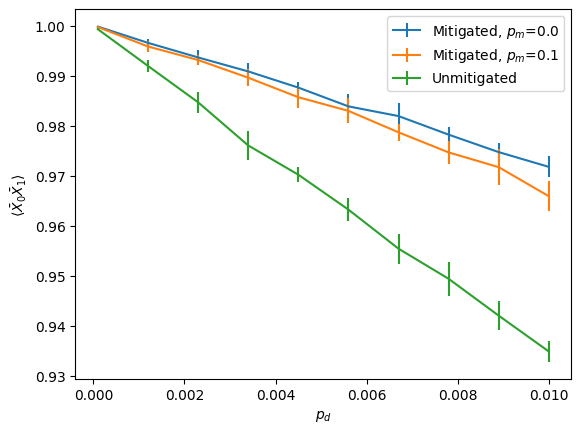

In [3]:
fig, ax = plt.subplots()
for meas_noise_rate in np.unique(df_m["meas_noise_rate"]):
    df_m_nr = df_m[df_m["meas_noise_rate"] == meas_noise_rate]
    ax.errorbar(df_m_nr["noise_rate"], df_m_nr["avg"], yerr=df_m_nr["std"], label=rf"Mitigated, $p_m$={meas_noise_rate}")
ax.errorbar(df_u["noise_rate"], df_u["avg"], yerr=df_u["std"], label="Unmitigated")
ax.legend()
ax.set_ylabel(r"$\langle \bar{X}_0\bar{X}_1 \rangle$")
ax.set_xlabel(r"$p_d$")

In [4]:
with open("eight_qubit_circuits.pkl", "rb") as f:
    input_dict= pickle.load(f)

encoding_ckt = input_dict["encoding"]
logical_h = input_dict["logical_h"]
logical_cx = input_dict["logical_cx"]
logical_ckt_stim = logical_h + logical_cx

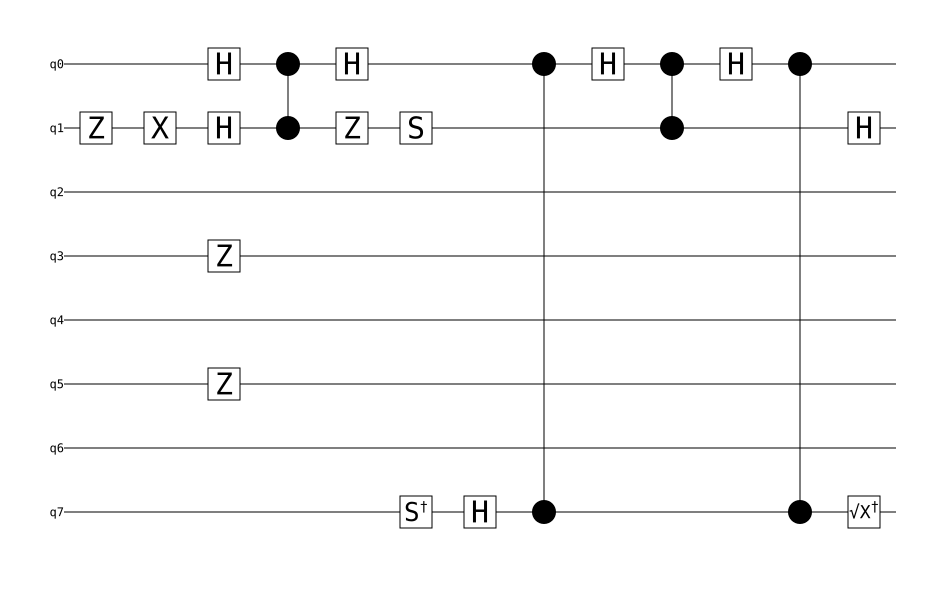

In [5]:
logical_h.diagram('timeline-svg')

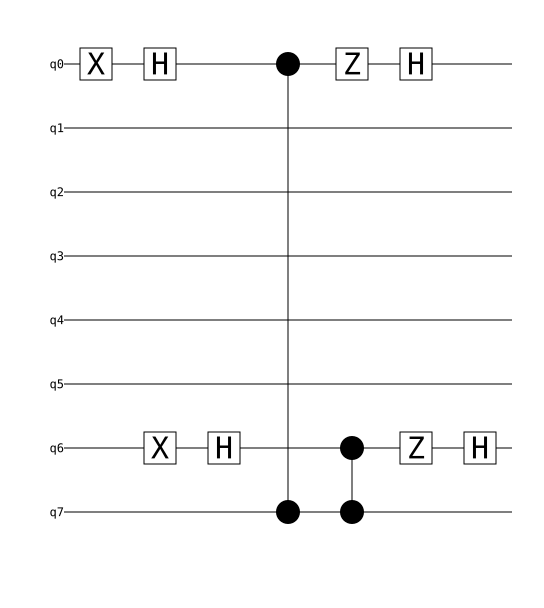

In [6]:
logical_cx.diagram('timeline-svg')